In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [14]:
ticker = "AAPL"

df = yf.download(
    ticker,
    start="2022-01-01",
    end="2024-01-01"
)

print(df.shape)
df.head()

[*********************100%***********************]  1 of 1 completed

(501, 5)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,177.939713,178.790267,173.735885,173.853197,104487900
2022-01-04,175.681381,178.848931,175.114350,178.545866,99310400
2022-01-05,171.008270,176.140865,170.734533,175.593390,94537600
2022-01-06,168.153564,171.379770,167.801615,168.837907,96904000
2022-01-07,168.319748,170.245694,167.205242,169.023648,86709100


In [15]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 501 entries, 2022-01-03 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   501 non-null    float64
 1   (High, AAPL)    501 non-null    float64
 2   (Low, AAPL)     501 non-null    float64
 3   (Open, AAPL)    501 non-null    float64
 4   (Volume, AAPL)  501 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.5 KB


In [16]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,501.000000,501.000000,501.000000,501.000000,5.010000e+02
mean,160.981680,162.643736,159.157569,160.822131,7.359559e+07
std,17.710740,17.443341,17.972579,17.743000,2.536654e+07
min,122.933525,125.637630,122.097723,123.907048,2.404830e+07
25%,146.648438,148.253943,144.773779,146.136419,5.414710e+07
50%,161.887604,163.084934,159.567642,161.496088,6.924600e+07
75%,173.880112,175.361363,171.974217,173.853197,8.670910e+07
max,195.892609,197.385702,194.795046,195.803620,1.826020e+08


In [17]:
df.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

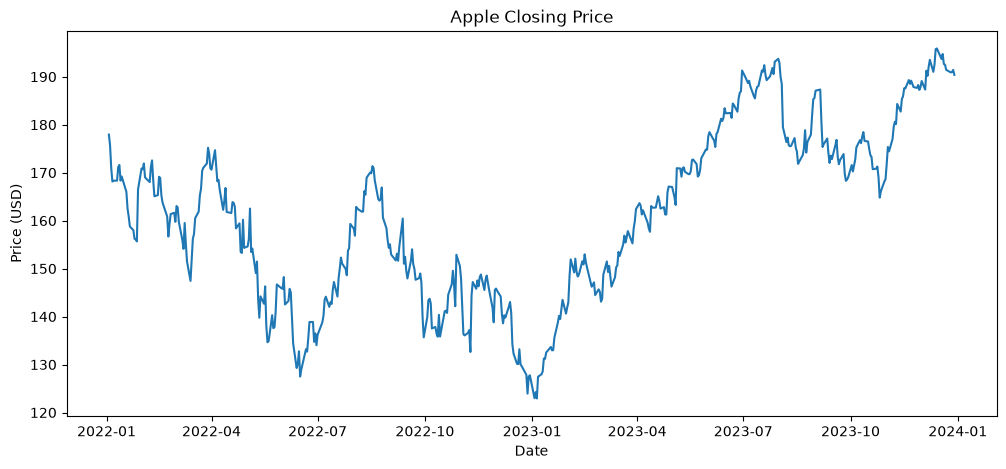

In [18]:
plt.figure(figsize=(12,5))

plt.plot(df["Close"])

plt.title("Apple Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.show()

In [19]:
df["Next_Close"] = df["Close"].shift(-1)

df = df.dropna()

df.head()

Price,Close,High,Low,Open,Volume,Next_Close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2022-01-03,177.939713,178.790267,173.735885,173.853197,104487900,175.681381
2022-01-04,175.681381,178.848931,175.114350,178.545866,99310400,171.008270
2022-01-05,171.008270,176.140865,170.734533,175.593390,94537600,168.153564
2022-01-06,168.153564,171.379770,167.801615,168.837907,96904000,168.319748
2022-01-07,168.319748,170.245694,167.205242,169.023648,86709100,168.339294


In [20]:
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

X = df[features]

y = df["Next_Close"]

print(X.shape)
print(y.shape)

(500, 5)
(500,)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle=False
)

print(len(X_train))
print(len(X_test))

400
100


In [22]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [23]:
y_pred = model.predict(X_test)

In [24]:
mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)

Mean Absolute Error: 1.8927934386338356
R² Score: 0.9165528937592433


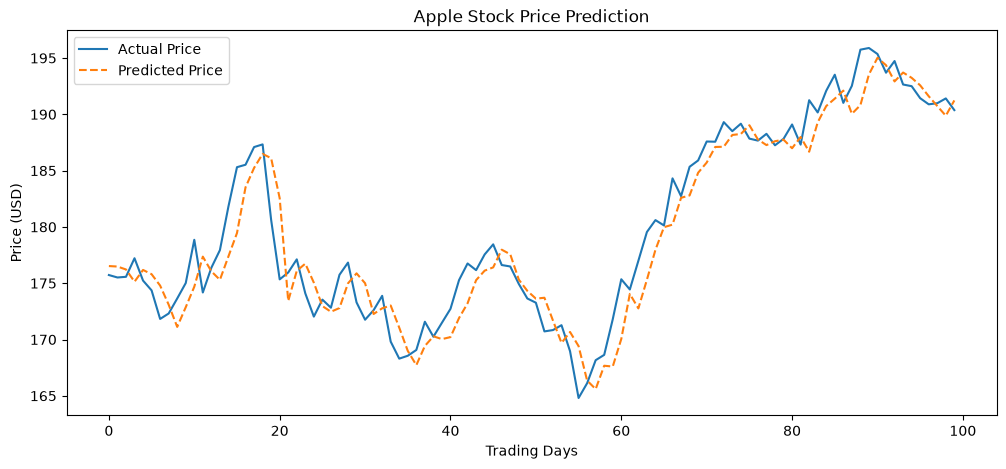

In [25]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred, "--", label="Predicted Price")

plt.title("Apple Stock Price Prediction")

plt.xlabel("Trading Days")
plt.ylabel("Price (USD)")

plt.legend()

plt.show()

# Task 2: Future Stock Price Prediction

## Objective
The goal of this project is to predict the next day's closing stock price using machine learning.

## Dataset
- Source: Yahoo Finance
- Stock: Apple (AAPL)
- Period: January 2022 to January 2024

## Model
- Linear Regression

## Features
- Open
- High
- Low
- Close
- Volume

## Target
- Next day's closing price

## Evaluation
- Mean Absolute Error (MAE)
- R² Score

## Conclusion
The model successfully learned the relationship between today's stock values and the next day's closing price. The predicted prices closely followed the actual prices, demonstrating the effectiveness of the regression model for this dataset.